# Experiments for Randers-Finsler HMC

In [1]:
import torch
from torch import Tensor
from geodesic_toolbox import ExplicitRHMCSampler, ExplicitFHMCLegendre, ImplicitFHMCUnbiased
from geodesic_toolbox.solvers import GEORCEFinsler
from geodesic_toolbox.cometric import DualRandersMetrics, CoMetric, OneForm_dtheta, IdentityCoMetric, RandersMetrics
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import gaussian_kde

## 1 - Definition of Randers Metric

We equipe the Euclidian space $(\mathbb R^2, \bar g)$ with the following one form : 
\begin{equation*}
    \omega = \frac{\eta}{\|d\theta\|}d\theta = \eta(\frac{-y}{\sqrt{x^2 + y^2}}dx + \frac{x}{\sqrt{x^2 +y^2}}dy)
\end{equation*}
where $0 \le \eta <1$ ensures that this defines a Randers metric. 

Visualization of the covector field.

In [2]:
eta = 0.6
omega_form = OneForm_dtheta(eta)
cometric = IdentityCoMetric()
randers_metric = RandersMetrics(cometric, omega_form)
randers_cometric = DualRandersMetrics(randers_metric)

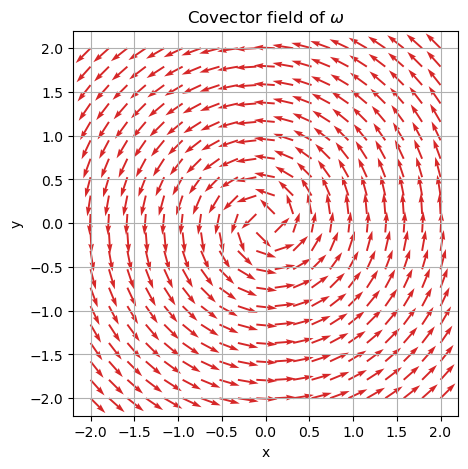

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
# Create a grid of points
x = np.linspace(-2, 2, 20)
y = np.linspace(-2, 2, 20)
xx, yy = np.meshgrid(x, y)
points = np.stack([xx.ravel(), yy.ravel()], axis=1)

# Avoid the origin to prevent division by zero
mask = np.linalg.norm(points, axis=1) > 0.1
masked_points = points[mask]
pts_tensor = torch.tensor(masked_points, dtype=torch.float32)
omega_vecs = omega_form(pts_tensor).detach().numpy()

ax.quiver(
    masked_points[:, 0],
    masked_points[:, 1],
    omega_vecs[:, 0],
    omega_vecs[:, 1],
    angles="xy",
    scale_units="xy",
    scale=2.5,
    color="tab:red",
    width=0.005,
)

ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Covector field of $\omega$")
ax.grid(True)
plt.show()

## 2 - Hamiltonian trajectories for Randers geodesics

### 2.3. Explicit solver

In [4]:
omega_form = OneForm_dtheta(eta)
randers_metric = RandersMetrics(cometric, omega_form)
randers_cometric = DualRandersMetrics(randers_metric)

l = 100
N_fx = 6
gamma = 0.01
N_run = 1

sampler = ImplicitFHMCUnbiased(
    randers_cometric,
    l, 
    N_fx,
    gamma, 
    N_run, 
    pbar = True,
    skip_acceptance = True
    )

In [5]:
z_0 = torch.tensor([[0.,1.]])
#z_1 = z_0.clone()
v_0 = torch.tensor([[1., 0.]])
p_0 = sampler.legendre(v_0, z_0)
#p_1 = p_0.clone()
#traj = sampler.leapfrog(z_0, p_0, z_1, p_1, return_traj=True)
dirs = torch.ones(z_0.shape[0])
traj = sampler.leapfrog(z_0, p_0, dirs, return_traj=True)

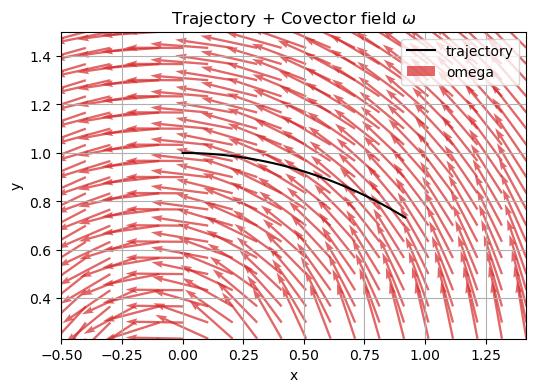

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))

# ---- Trajectory ----
positions = traj[0][0].detach().numpy()  # shape (l+1, d)
ax.plot(positions[:, 0], positions[:, 1], color='black', label="trajectory")

# ---- Define plotting window from trajectory ----
xmin, xmax = positions[:, 0].min(), positions[:, 0].max()
ymin, ymax = positions[:, 1].min(), positions[:, 1].max()

# Add margin
margin = 0.5
xmin -= margin; xmax += margin
ymin -= margin; ymax += margin

# ---- Grid adapted to trajectory frame ----
x = np.linspace(xmin, xmax, 20)
y = np.linspace(ymin, ymax, 20)
xx, yy = np.meshgrid(x, y)
points = np.stack([xx.ravel(), yy.ravel()], axis=1)

# Avoid origin if needed
mask = np.linalg.norm(points, axis=1) > 0.1
masked_points = points[mask]

pts_tensor = torch.tensor(masked_points, dtype=torch.float32)
omega_vecs = omega_form(pts_tensor).detach().numpy()

# ---- Covector field ----
ax.quiver(
    masked_points[:, 0],
    masked_points[:, 1],
    omega_vecs[:, 0],
    omega_vecs[:, 1],
    angles="xy",
    scale_units="xy",
    scale=2.5,
    color="tab:red",
    width=0.005,
    alpha=0.7,
    label="omega"
)

# ---- Styling ----
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Trajectory + Covector field $\omega$")
ax.grid(True)
ax.legend()

plt.show()

## 3- Tests for FHMC algorithm with difference acceptation rates

## 3.1. FHMC without rejection (or geodesic Random Walk)

In [7]:
eta = 0.6
alpha = torch.Tensor([0.1])
cometric = IdentityCoMetric()
omega_form = OneForm_dtheta(eta)
randers_metric = RandersMetrics(cometric, omega_form)
randers_cometric = DualRandersMetrics(randers_metric)

l = 1
gamma = 0.01
omega = 10.
N_run = 1000
N_fx = 6

sampler = ImplicitFHMCUnbiased(
    randers_cometric,
    l, 
    N_fx,
    gamma, 
    N_run, 
    pbar = True,
    skip_acceptance = True
    )

Initial momentum and velocity distribution

In [8]:
z_0 = torch.tensor([[0., 1.]]*10**4)

G_star = randers_cometric.G_star(z_0)[0,...]
w_star = randers_cometric.omega_star(z_0)[0,...]
p_0 = sampler.sample_momentum(z_0)
v_0 = sampler.reversed_legendre(p_0, z_0)

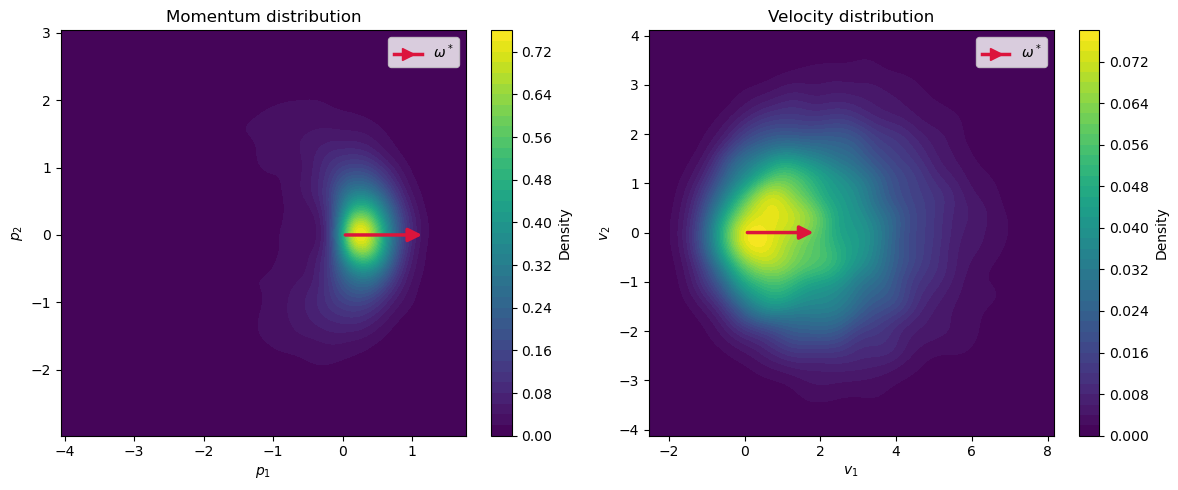

In [9]:
import matplotlib.lines as mlines

# Convert to numpy
p_np = p_0.detach().cpu().numpy()
v_np = v_0.detach().cpu().numpy()
w_np = w_star.detach().cpu().numpy()

# --- Auto-adapt bounds: 0.5–99.5 percentile + 15% margin ---
def auto_bounds(data, q_lo=0.5, q_hi=99.5, margin=0.15):
    lo = np.percentile(data, q_lo, axis=0)
    hi = np.percentile(data, q_hi, axis=0)
    span = hi - lo
    return lo - margin * span, hi + margin * span

p_lo, p_hi = auto_bounds(p_np)
v_lo, v_hi = auto_bounds(v_np)

grid_size = 150

def make_grid(lo, hi, n=grid_size):
    xx, yy = np.meshgrid(np.linspace(lo[0], hi[0], n), np.linspace(lo[1], hi[1], n))
    return xx, yy, np.vstack([xx.ravel(), yy.ravel()])

p_xx, p_yy, p_pts = make_grid(p_lo, p_hi)
v_xx, v_yy, v_pts = make_grid(v_lo, v_hi)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

def plot_panel(ax, data, xx, yy, pts, lo, hi, xlabel, ylabel, title, arrow_w):
    kde = gaussian_kde(data.T)
    zz = kde(pts).reshape(xx.shape)
    cf = ax.contourf(xx, yy, zz, levels=40, cmap="viridis")
    plt.colorbar(cf, ax=ax, label="Density")

    # Arrow scaled to 20% of the plot span, unit-direction normalised
    scale = 0.2 * np.mean(hi - lo) / (np.linalg.norm(arrow_w) + 1e-12)
    dx, dy = scale * arrow_w[0], scale * arrow_w[1]
    ax.annotate("", xy=(dx, dy), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color="crimson",
                                lw=2.5, mutation_scale=20))

    proxy = mlines.Line2D([], [], color="crimson", lw=2.5,
                          marker=">", markersize=9, label=r"$\omega^*$")
    ax.legend(handles=[proxy], loc="upper right", framealpha=0.8)
    ax.set_xlim(lo[0], hi[0])
    ax.set_ylim(lo[1], hi[1])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

plot_panel(axs[0], p_np, p_xx, p_yy, p_pts, p_lo, p_hi,
           "$p_1$", "$p_2$", "Momentum distribution", w_np)
plot_panel(axs[1], v_np, v_xx, v_yy, v_pts, v_lo, v_hi,
           "$v_1$", "$v_2$", "Velocity distribution", w_np)

plt.tight_layout()
plt.show()

Full trajectories

In [10]:
n_traj = 100
traj = sampler.sample(
    z_0 = torch.tensor([[0., 1.]]*n_traj),
    return_traj= True, 
    progress=True
)

Sampling:   0%|          | 0/1000 [00:00<?, ?steps/s]

Sampling: 100%|██████████| 1000/1000 [00:24<00:00, 40.58steps/s, acceptance_rate=1]


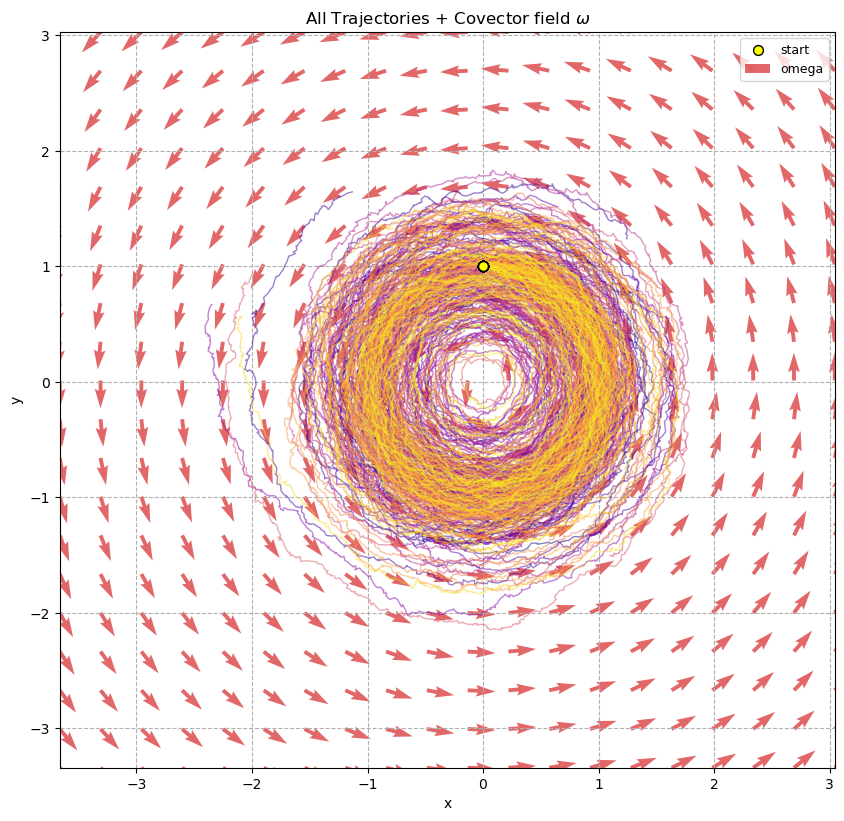

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))

# ---- Trajectories ----
positions = traj.detach().cpu().numpy() if hasattr(traj, "detach") else np.asarray(traj)
if isinstance(positions, tuple):
    positions = positions[2]  # fallback for old traj structure
positions = np.asarray(positions)

# Automatically determine plotting window based on trajectory data, with some margin
margin = 0.3  # as ratio of span
x_min_traj = np.nanmin(positions[..., 0])
x_max_traj = np.nanmax(positions[..., 0])
y_min_traj = np.nanmin(positions[..., 1])
y_max_traj = np.nanmax(positions[..., 1])

x_span = x_max_traj - x_min_traj
y_span = y_max_traj - y_min_traj

xmin = x_min_traj - margin * x_span
xmax = x_max_traj + margin * x_span
ymin = y_min_traj - margin * y_span
ymax = y_max_traj + margin * y_span

if positions.ndim == 3:
    n_paths, n_steps, dim = positions.shape
    # Color for each path
    cmap = plt.get_cmap('plasma')
    colors = cmap(np.linspace(0, 1, n_paths))
    # Plot each trajectory (only plotting within window)
    for i in range(n_paths):
        path_x = positions[i, :, 0]
        path_y = positions[i, :, 1]
        mask = (
            (path_x >= xmin) & (path_x <= xmax) &
            (path_y >= ymin) & (path_y <= ymax)
        )
        segment_mask = mask
        if segment_mask.any():
            ax.plot(
                path_x[segment_mask],
                path_y[segment_mask],
                color=colors[i],
                alpha=0.5,
                linewidth=1.0,
            )
    # Mark starting points in yellow if they're inside plotting window
    in_box = (
        (positions[:, 0, 0] >= xmin) & (positions[:, 0, 0] <= xmax) &
        (positions[:, 0, 1] >= ymin) & (positions[:, 0, 1] <= ymax)
    )
    if in_box.any():
        ax.scatter(
            positions[:, 0, 0][in_box], positions[:, 0, 1][in_box],
            color="yellow", edgecolor="black", s=50, marker="o", zorder=6, label="start"
        )
else:
    # fallback to a single trajectory
    path_x = positions[:, 0]
    path_y = positions[:, 1]
    mask = (
        (path_x >= xmin) & (path_x <= xmax) &
        (path_y >= ymin) & (path_y <= ymax)
    )
    if mask.any():
        ax.plot(
            path_x[mask],
            path_y[mask],
            color='black',
            alpha=0.5,
            linewidth=1.0,
            label="trajectory"
        )
    # Mark starting point in yellow if it's in plotting window
    if xmin <= positions[0, 0] <= xmax and ymin <= positions[0, 1] <= ymax:
        ax.scatter(
            positions[0, 0], positions[0, 1],
            color="yellow", edgecolor="black", s=70, marker="o", zorder=6, label="start"
        )

# ---- Define grid within the window (adaptive to data) ----
x = np.linspace(xmin, xmax, 20)
y = np.linspace(ymin, ymax, 20)
xx, yy = np.meshgrid(x, y)
points = np.stack([xx.ravel(), yy.ravel()], axis=1)

# Avoid origin if needed
mask = np.linalg.norm(points, axis=1) > 0.1
masked_points = points[mask]

pts_tensor = torch.tensor(masked_points, dtype=torch.float32)
omega_vecs = omega_form(pts_tensor).detach().numpy()

# ---- Covector field ----
ax.quiver(
    masked_points[:, 0],
    masked_points[:, 1],
    omega_vecs[:, 0],
    omega_vecs[:, 1],
    angles="xy",
    scale_units="xy",
    scale=2.5,
    color="tab:red",
    width=0.005,
    alpha=0.7,
    label="omega"
)

# ---- Styling ----
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"All Trajectories + Covector field $\omega$")
ax.grid(True, linestyle ="--")
ax.legend(loc="upper right", fontsize=9)

plt.show()

## 3.2. FHMC : acceptation ratio as likelihood ratio

In [12]:
eta = 0.6
alpha = torch.Tensor([0.1])
cometric = IdentityCoMetric()
omega_form = OneForm_dtheta(eta)
randers_metric = RandersMetrics(cometric, omega_form)
randers_cometric = DualRandersMetrics(randers_metric)
l = 1
gamma = 0.01
omega = 10.
N_run = 1000
N_fx = 6


sampler = ImplicitFHMCUnbiased(
    randers_cometric,
    l, 
    N_fx,
    gamma, 
    N_run, 
    pbar = True, 
    reduced_flip= False
    )


sampler_optimized = ImplicitFHMCUnbiased(
    randers_cometric,
    l, 
    N_fx,
    gamma, 
    N_run, 
    pbar = True
    )

In [13]:
traj, acc, flip = sampler.sample(
    z_0 = torch.tensor([[0.,1.]]*100),
    return_traj= True, 
    return_acceptance= True,
    progress = True,
    return_flip = True
)
print(f"Acceptance rate: {acc:.4f}")
print(f"Momentum flip rate: {flip:.4f}")

Sampling: 100%|██████████| 1000/1000 [00:11<00:00, 84.94steps/s, acceptance_rate=0.995]

Acceptance rate: 0.9954
Momentum flip rate: 0.0046


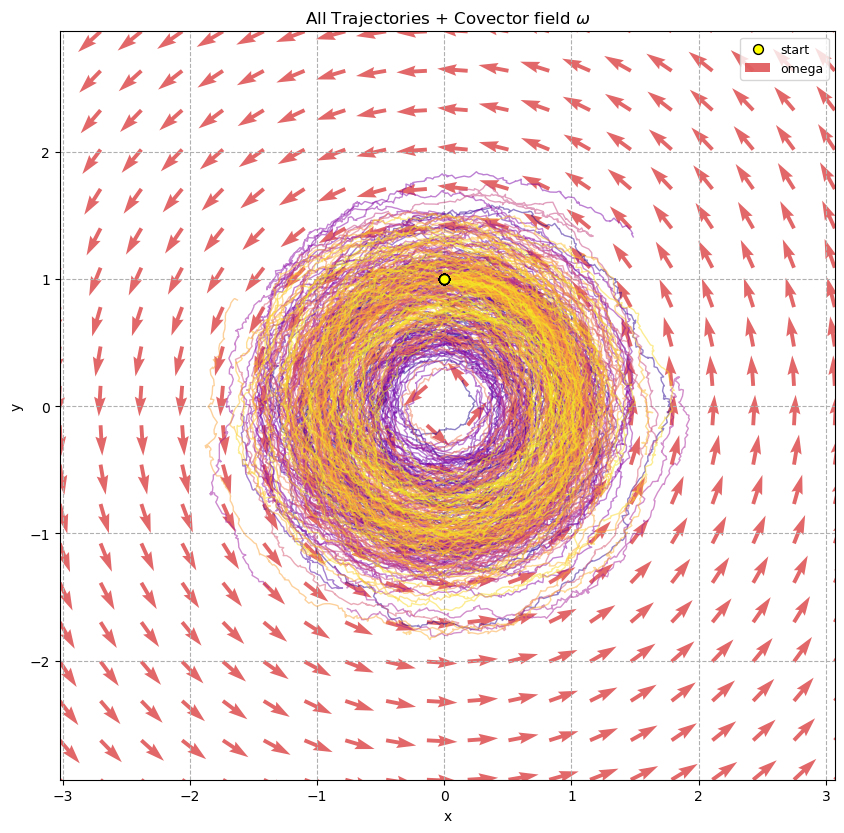

In [14]:
fig, ax = plt.subplots(figsize=(10, 10))

# ---- Trajectories ----
positions = traj.detach().cpu().numpy() if hasattr(traj, "detach") else np.asarray(traj)
if isinstance(positions, tuple):
    positions = positions[2]  # fallback for old traj structure
positions = np.asarray(positions)

# Automatically determine plotting window based on trajectory data, with some margin
margin = 0.3  # as ratio of span
x_min_traj = np.nanmin(positions[..., 0])
x_max_traj = np.nanmax(positions[..., 0])
y_min_traj = np.nanmin(positions[..., 1])
y_max_traj = np.nanmax(positions[..., 1])

x_span = x_max_traj - x_min_traj
y_span = y_max_traj - y_min_traj

xmin = x_min_traj - margin * x_span
xmax = x_max_traj + margin * x_span
ymin = y_min_traj - margin * y_span
ymax = y_max_traj + margin * y_span

if positions.ndim == 3:
    n_paths, n_steps, dim = positions.shape
    # Color for each path
    cmap = plt.get_cmap('plasma')
    colors = cmap(np.linspace(0, 1, n_paths))
    # Plot each trajectory (only plotting within window)
    for i in range(n_paths):
        path_x = positions[i, :, 0]
        path_y = positions[i, :, 1]
        mask = (
            (path_x >= xmin) & (path_x <= xmax) &
            (path_y >= ymin) & (path_y <= ymax)
        )
        segment_mask = mask
        if segment_mask.any():
            ax.plot(
                path_x[segment_mask],
                path_y[segment_mask],
                color=colors[i],
                alpha=0.5,
                linewidth=1.0,
            )
    # Mark starting points in yellow if they're inside plotting window
    in_box = (
        (positions[:, 0, 0] >= xmin) & (positions[:, 0, 0] <= xmax) &
        (positions[:, 0, 1] >= ymin) & (positions[:, 0, 1] <= ymax)
    )
    if in_box.any():
        ax.scatter(
            positions[:, 0, 0][in_box], positions[:, 0, 1][in_box],
            color="yellow", edgecolor="black", s=50, marker="o", zorder=6, label="start"
        )
else:
    # fallback to a single trajectory
    path_x = positions[:, 0]
    path_y = positions[:, 1]
    mask = (
        (path_x >= xmin) & (path_x <= xmax) &
        (path_y >= ymin) & (path_y <= ymax)
    )
    if mask.any():
        ax.plot(
            path_x[mask],
            path_y[mask],
            color='black',
            alpha=0.5,
            linewidth=1.0,
            label="trajectory"
        )
    # Mark starting point in yellow if it's in plotting window
    if xmin <= positions[0, 0] <= xmax and ymin <= positions[0, 1] <= ymax:
        ax.scatter(
            positions[0, 0], positions[0, 1],
            color="yellow", edgecolor="black", s=70, marker="o", zorder=6, label="start"
        )

# ---- Define grid within the window (adaptive to data) ----
x = np.linspace(xmin, xmax, 20)
y = np.linspace(ymin, ymax, 20)
xx, yy = np.meshgrid(x, y)
points = np.stack([xx.ravel(), yy.ravel()], axis=1)

# Avoid origin if needed
mask = np.linalg.norm(points, axis=1) > 0.1
masked_points = points[mask]

pts_tensor = torch.tensor(masked_points, dtype=torch.float32)
omega_vecs = omega_form(pts_tensor).detach().numpy()

# ---- Covector field ----
ax.quiver(
    masked_points[:, 0],
    masked_points[:, 1],
    omega_vecs[:, 0],
    omega_vecs[:, 1],
    angles="xy",
    scale_units="xy",
    scale=2.5,
    color="tab:red",
    width=0.005,
    alpha=0.7,
    label="omega"
)

# ---- Styling ----
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"All Trajectories + Covector field $\omega$")
ax.grid(True, linestyle ="--")
ax.legend(loc="upper right", fontsize=9)

plt.show()

In [15]:
traj, acc, flip = sampler_optimized.sample(
    z_0 = torch.tensor([[0.,1.]]*100),
    return_traj= True, 
    return_acceptance= True,
    progress = True,
    return_flip = True
)
print(f"Acceptance rate: {acc:.4f}")
print(f"Momentum flip rate: {flip:.4f}")

Sampling: 100%|██████████| 1000/1000 [00:20<00:00, 48.96steps/s, acceptance_rate=0.996]


Acceptance rate: 0.9955
Momentum flip rate: 0.0045


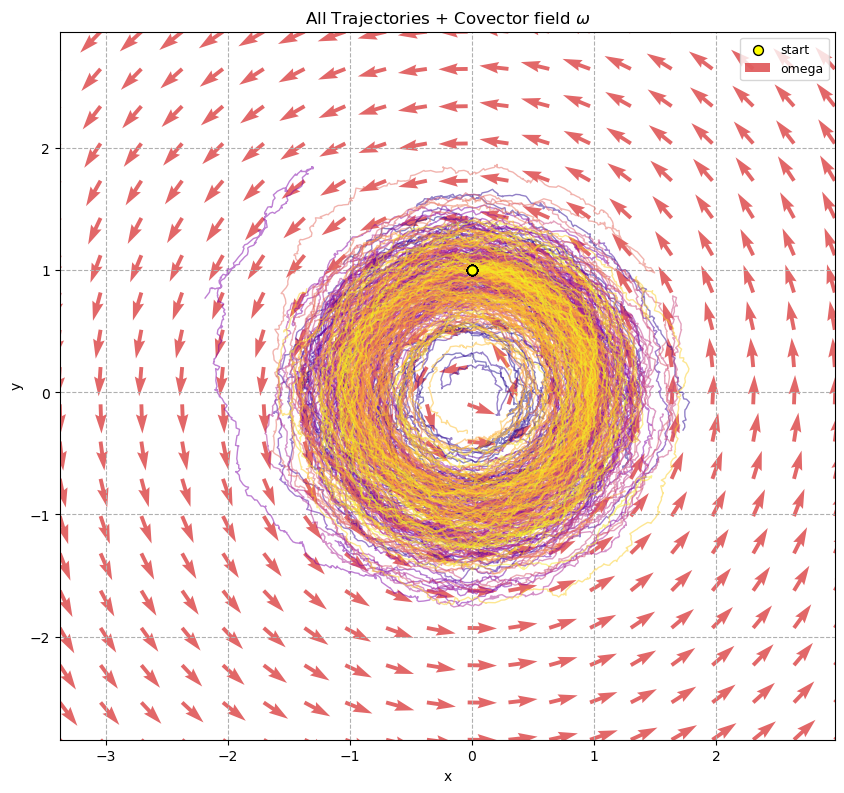

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))

# ---- Trajectories ----
positions = traj.detach().cpu().numpy() if hasattr(traj, "detach") else np.asarray(traj)
if isinstance(positions, tuple):
    positions = positions[2]  # fallback for old traj structure
positions = np.asarray(positions)

# Automatically determine plotting window based on trajectory data, with some margin
margin = 0.3  # as ratio of span
x_min_traj = np.nanmin(positions[..., 0])
x_max_traj = np.nanmax(positions[..., 0])
y_min_traj = np.nanmin(positions[..., 1])
y_max_traj = np.nanmax(positions[..., 1])

x_span = x_max_traj - x_min_traj
y_span = y_max_traj - y_min_traj

xmin = x_min_traj - margin * x_span
xmax = x_max_traj + margin * x_span
ymin = y_min_traj - margin * y_span
ymax = y_max_traj + margin * y_span

if positions.ndim == 3:
    n_paths, n_steps, dim = positions.shape
    # Color for each path
    cmap = plt.get_cmap('plasma')
    colors = cmap(np.linspace(0, 1, n_paths))
    # Plot each trajectory (only plotting within window)
    for i in range(n_paths):
        path_x = positions[i, :, 0]
        path_y = positions[i, :, 1]
        mask = (
            (path_x >= xmin) & (path_x <= xmax) &
            (path_y >= ymin) & (path_y <= ymax)
        )
        segment_mask = mask
        if segment_mask.any():
            ax.plot(
                path_x[segment_mask],
                path_y[segment_mask],
                color=colors[i],
                alpha=0.5,
                linewidth=1.0,
            )
    # Mark starting points in yellow if they're inside plotting window
    in_box = (
        (positions[:, 0, 0] >= xmin) & (positions[:, 0, 0] <= xmax) &
        (positions[:, 0, 1] >= ymin) & (positions[:, 0, 1] <= ymax)
    )
    if in_box.any():
        ax.scatter(
            positions[:, 0, 0][in_box], positions[:, 0, 1][in_box],
            color="yellow", edgecolor="black", s=50, marker="o", zorder=6, label="start"
        )
else:
    # fallback to a single trajectory
    path_x = positions[:, 0]
    path_y = positions[:, 1]
    mask = (
        (path_x >= xmin) & (path_x <= xmax) &
        (path_y >= ymin) & (path_y <= ymax)
    )
    if mask.any():
        ax.plot(
            path_x[mask],
            path_y[mask],
            color='black',
            alpha=0.5,
            linewidth=1.0,
            label="trajectory"
        )
    # Mark starting point in yellow if it's in plotting window
    if xmin <= positions[0, 0] <= xmax and ymin <= positions[0, 1] <= ymax:
        ax.scatter(
            positions[0, 0], positions[0, 1],
            color="yellow", edgecolor="black", s=70, marker="o", zorder=6, label="start"
        )

# ---- Define grid within the window (adaptive to data) ----
x = np.linspace(xmin, xmax, 20)
y = np.linspace(ymin, ymax, 20)
xx, yy = np.meshgrid(x, y)
points = np.stack([xx.ravel(), yy.ravel()], axis=1)

# Avoid origin if needed
mask = np.linalg.norm(points, axis=1) > 0.1
masked_points = points[mask]

pts_tensor = torch.tensor(masked_points, dtype=torch.float32)
omega_vecs = omega_form(pts_tensor).detach().numpy()

# ---- Covector field ----
ax.quiver(
    masked_points[:, 0],
    masked_points[:, 1],
    omega_vecs[:, 0],
    omega_vecs[:, 1],
    angles="xy",
    scale_units="xy",
    scale=2.5,
    color="tab:red",
    width=0.005,
    alpha=0.7,
    label="omega"
)

# ---- Styling ----
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"All Trajectories + Covector field $\omega$")
ax.grid(True, linestyle ="--")
ax.legend(loc="upper right", fontsize=9)

plt.show()